In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
! pip install kagglehub

^C


### Downloading 'Zomato' Dataset from Kaggle


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

os.makedirs("data", exist_ok=True)

file_path = "../data/zomato.csv"

!kaggle datasets download -d bhanupratapbiswas/zomato -p ../data/zomato.csv --unzip


In [53]:
df = pd.read_csv("..\data\zomato.csv\zomato.csv")

In [56]:
df["listed_in(type)"].value_counts()[7:].count()

2776

In [59]:
top7_indices = df["listed_in(type)"].value_counts()[:7]
print(top7_indices)

Delivery              24317
Dine-out              16253
Desserts               3379
Cafes                  1461
Drinks & nightlife      751
Buffet                  693
Pubs and bars           515
Name: listed_in(type), dtype: int64


In [8]:
df.describe(include='all')

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [10]:
# droping the phone column

df.drop(['phone'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   location                     56126 non-null  object
 7   rest_type                    55914 non-null  object
 8   dish_liked                   28027 non-null  object
 9   cuisines                     56049 non-null  object
 10  approx_cost(for two people)  55731 non-null  object
 11  listed_in(type)              51642 non-null  object
dtypes: object(12)
memory usage: 5.2+ MB


In [11]:
df.isnull().sum()

address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64

In [12]:
df['address'].value_counts()

 ('Rated 4.0'                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           942
 ('Rated 5.0'                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [13]:
df['location'].value_counts()

BTM                                                                                                                                                                                                                                                                           5125
HSR                                                                                                                                                                                                                                                                           2523
Koramangala 5th Block                                                                                                                                                                                                                                                         2504
JP Nagar                                                                                                                                                                       

In [14]:
df['online_order'].value_counts()

Yes                                                                                                                                                                                                                                                                                                                                                                                                       30444
No                                                                                                                                                                                                                                                                                                                                                                                                        21273
 ('Rated 4.0'                                                                                                                                                                                           

In [15]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [16]:
df['book_table'].value_counts()

No                                                                                                                                                                                                                                                                              45268
Yes                                                                                                                                                                                                                                                                              6449
 ('Rated 4.0'                                                                                                                                                                                                                                                                     384
 ('Rated 5.0'                                                                                                                                                         

In [17]:
df['rate'].value_counts()

NEW                                                                                                                                                                                                                                                                                                            2208
3.9/5                                                                                                                                                                                                                                                                                                          2098
3.8/5                                                                                                                                                                                                                                                                                                          2022
3.7/5                                                                       

In [18]:
df['votes']

0        775
1        787
2        918
3         88
4        166
        ... 
56247     27
56248      0
56249      0
56250    236
56251     13
Name: votes, Length: 56252, dtype: object

In [19]:
df['votes'].value_counts()

0                                                                                                                                                                                                                     10027
4                                                                                                                                                                                                                      1140
6                                                                                                                                                                                                                       992
7                                                                                                                                                                                                                       872
9                                                                                                                       

In [20]:
df['location'].value_counts()

BTM                                                                                                                                                                                                                                                                           5125
HSR                                                                                                                                                                                                                                                                           2523
Koramangala 5th Block                                                                                                                                                                                                                                                         2504
JP Nagar                                                                                                                                                                       

In [21]:
df['rest_type'].value_counts()

Quick Bites                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 19132
Casual Dining                                                                                                                                                                                                                                                                         

In [22]:
df['dish_liked'].value_counts()

 ('Rated 4.0'                                                                                                                                                                                                                   407
 ('Rated 5.0'                                                                                                                                                                                                                   328
Biryani                                                                                                                                                                                                                         182
 ('Rated 3.0'                                                                                                                                                                                                                   156
 ('Rated 1.0'                                                                           

In [23]:
df['cuisines'].value_counts()

North Indian                                                                                                        2913
North Indian, Chinese                                                                                               2385
South Indian                                                                                                        1828
Biryani                                                                                                              918
Bakery, Desserts                                                                                                     911
                                                                                                                    ... 
the service is a bit slow                                                                                              1
 sizzlers                                                                                                              1
 and the potion was suffice. The

In [24]:
df['approx_cost(for two people)'].value_counts()

300                                                                                                                                                                          7576
400                                                                                                                                                                          6562
500                                                                                                                                                                          4980
200                                                                                                                                                                          4857
600                                                                                                                                                                          3714
                                                                                                              

In [25]:
df['listed_in(type)'].value_counts()

Delivery                                                                                                                                                                                                                     24317
Dine-out                                                                                                                                                                                                                     16253
Desserts                                                                                                                                                                                                                      3379
Cafes                                                                                                                                                                                                                         1461
Drinks & nightlife                                                                          

### Data Cleaning

#### Rate Column and Online Order Column

In [26]:
import re
import numpy as np
import pandas as pd

def clean_online_order(df, fill_missing=True):
    """
    Cleans the 'online_order' column in the Zomato dataset:
    - Keeps only Yes/No as valid categories.
    - Moves misplaced rating-like values to 'rate'.
    - Marks gibberish/review text as NaN.
    - Optionally fills missing with mode (default: True).
    """

    cleaned_vals = []

    for idx, val in df["online_order"].astype(str).items():
        val_clean = val.strip().lower()

        # Case 1: Valid categories
        if val_clean in ["yes", "no"]:
            cleaned_vals.append(val_clean.capitalize())  # "Yes" / "No"

        # Case 2: Rating-like values (e.g. "Rated 4.0", "4.1/5")
        elif re.search(r"rated\s*\d+(\.\d+)?", val_clean) or re.search(r"\d+(\.\d+)?/5", val_clean):
            if pd.isna(df.loc[idx, "rate"]):
                df.loc[idx, "rate"] = val
            cleaned_vals.append(np.nan)

        # Case 3: Gibberish (long text, review, random junk)
        elif len(val_clean.split()) > 3:  # more than 3 words → likely review text
            cleaned_vals.append(np.nan)

        # Case 4: Fallback → mark as NaN
        else:
            cleaned_vals.append(np.nan)

    df["online_order"] = cleaned_vals

    # Step 4: Fill NaN with mode if requested
    if fill_missing:
        mode_value = df["online_order"].mode()[0]
        df["online_order"] = df["online_order"].fillna(mode_value)

    return df

df = clean_online_order(df)

In [27]:
import re
import numpy as np

def clean_online_order(df):
    """
    - Normalizes Yes/No.
    - Detects rating-like misplaced entries using regex and moves them to 'rate'.
    - Leaves gibberish as NaN (to be dropped or imputed later).
    """

    # Step 1: Normalize casing
    df["online_order"] = df["online_order"].astype(str).str.strip().str.lower()
    df["online_order"] = df["online_order"].map({"yes": "Yes", "no": "No"})

    # Step 2: Identify invalid entries
    mask_invalid = df["online_order"].isna()

    if "rate" in df.columns:
        for idx in df[mask_invalid].index:
            val = str(df.loc[idx, "online_order"])  # original bad value

            # Regex check: is it a rating? e.g. "4.1/5" or "Rated 4.0"
            if re.search(r"\d+(\.\d+)?", val):
                # move only rating-like values into 'rate'
                if pd.isna(df.loc[idx, "rate"]):
                    df.loc[idx, "rate"] = val
            else:
                # gibberish → leave as NaN for online_order
                df.loc[idx, "online_order"] = np.nan

    # Step 3: Fill NaN with mode (Yes/No)
    mode_value = df["online_order"].mode()[0]
    df["online_order"] = df["online_order"].fillna(mode_value)

    return df
df = clean_online_order(df)

In [28]:
df['online_order'].value_counts()

Yes    34979
No     21273
Name: online_order, dtype: int64

In [29]:
34979 + 21273

56252

In [30]:
df['rate'].value_counts()

NEW                                                                                                                                                                                                                                                                                                            2208
3.9/5                                                                                                                                                                                                                                                                                                          2098
3.8/5                                                                                                                                                                                                                                                                                                          2022
3.7/5                                                                       

In [31]:
import pandas as pd
import numpy as np

def clean_rate_column(df):
    def parse_rate(x):
        if pd.isna(x):
            return np.nan

        x = str(x).strip()

        # Case 1: "4.1/5"
        if "/" in x:
            try:
                return float(x.split("/")[0])
            except:
                return np.nan

        # Case 2: "Rated 4.0"
        if "Rated" in x:
            try:
                return float(x.replace("(Rated", "").strip())
            except:
                return np.nan

        # Case 3: anything else → NaN
        return np.nan

    # Apply parsing
    df["clean_rate"] = df["rate"].apply(parse_rate)

    # Fill NaN with average
    df["clean_rate"] = df.groupby("location")["clean_rate"].transform(
    lambda x: x.fillna(x.mean()))
    
    # Round to one decimal place
    df["clean_rate"] = df["clean_rate"].round(1)
   

    return df

# Usage
df = clean_rate_column(df)


In [32]:
df['clean_rate'].value_counts()

3.7    6313
3.6    5996
3.5    5465
3.8    5134
3.9    4464
4.0    3426
4.1    2990
3.4    2516
3.3    2320
4.2    2184
3.2    1967
4.3    1693
3.1    1561
4.4    1147
3.0    1023
2.9     802
4.5     656
2.8     600
2.7     307
4.6     300
2.6     260
4.7     167
2.5     101
2.4      70
4.8      66
4.9      55
2.3      51
2.2      26
2.1      24
2.0      11
1.8       5
Name: clean_rate, dtype: int64

In [33]:
# Define a function to clean 'online_order' and 'book_table' columns
def clean_binary_columns(value):
    if value == 'Yes':
        return 1
    elif value == 'No':
        return 0
    else:
        return pd.NaT

# Clean 'online_orderd' and 'book_table' columns
df['online_order'] = df['online_order'].apply(clean_binary_columns)
df['book_table'] = df['book_table'].apply(clean_binary_columns)

# Remove '/5' from 'rate' and convert to numeric
df['rate'] = df['rate'].str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Convert 'votes' to numeric
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# Remove commas from 'approx_cost(for two people)' and convert to numeric
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Remove listed_in column
# df = df.drop(columns=['listed_in(type)'])

In [34]:
df['rate'].isna().sum()

14587

In [35]:
df['location'].value_counts()

BTM                                                                                                                                                                                                                                                                           5125
HSR                                                                                                                                                                                                                                                                           2523
Koramangala 5th Block                                                                                                                                                                                                                                                         2504
JP Nagar                                                                                                                                                                       

In [36]:
def clean_categorical_columns(value, common_values):
    if pd.isnull(value):
        return pd.NaT
    elif value in common_values:
        return value
    else:
        return 'Other'
    
top_locations = df['location'].value_counts()[:10].index.tolist()

df['location'] = df['location'].apply(clean_categorical_columns, common_values=top_locations)

df["listed_in(type)"] = df['listed_in(type)'].apply(clean_categorical_columns, common_values =top7_indices )

In [37]:
df['listed_in(type)'].value_counts()

Delivery              24317
Dine-out              16253
Other                  4273
Desserts               3379
Cafes                  1461
Drinks & nightlife      751
Buffet                  693
Pubs and bars           515
Name: listed_in(type), dtype: int64

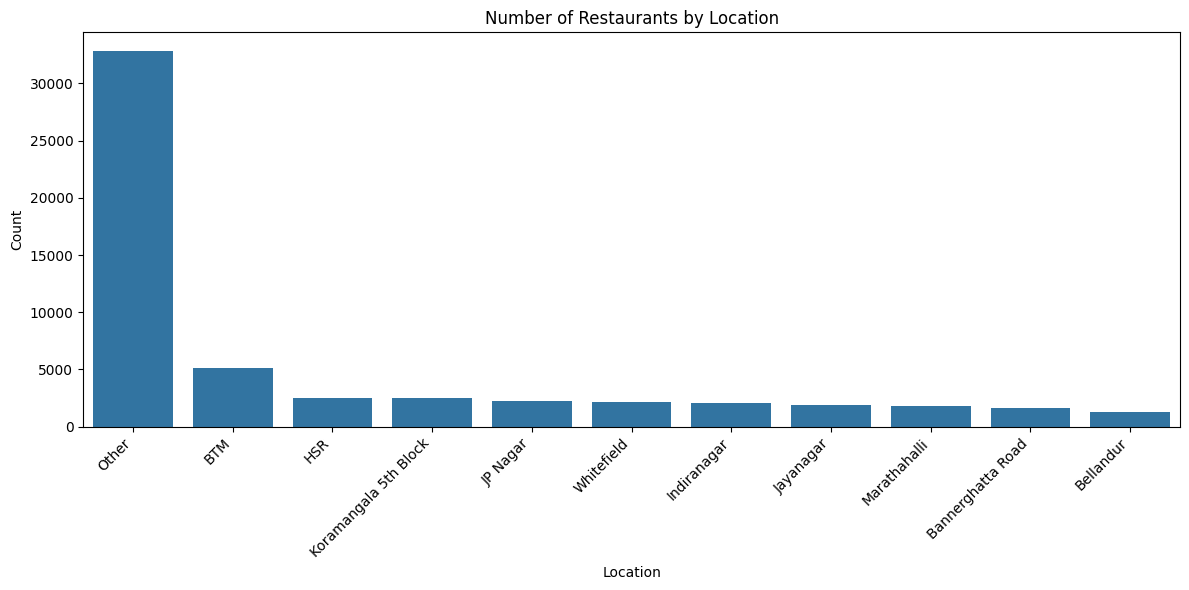

In [38]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['location'].value_counts().index, y=df['location'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Number of Restaurants by Location')
plt.tight_layout()
plt.show()


In [39]:
df['rest_type'].value_counts()

Quick Bites                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 19132
Casual Dining                                                                                                                                                                                                                                                                         

In [40]:
def map_rest_type(rest_type):
    if pd.isnull(rest_type):
        return 'Other'
    rest_type = rest_type.lower()
    if 'quick' in rest_type:
        return 'Quick Bites'
    elif 'casual' in rest_type:
        return 'Casual Dining'
    elif 'cafe' in rest_type:
        return 'Cafe'
    elif 'delivery' in rest_type:
        return 'Delivery'
    elif 'dessert' in rest_type:
        return 'Dessert Parlor'
    elif 'bar' in rest_type:
        return 'Bar'
    else:
        return 'Other'

df['rest_type'] = df['rest_type'].apply(map_rest_type)
df['rest_type'].value_counts()


Quick Bites       20713
Casual Dining     13059
Other              9634
Delivery           4693
Cafe               4488
Dessert Parlor     2780
Bar                 885
Name: rest_type, dtype: int64

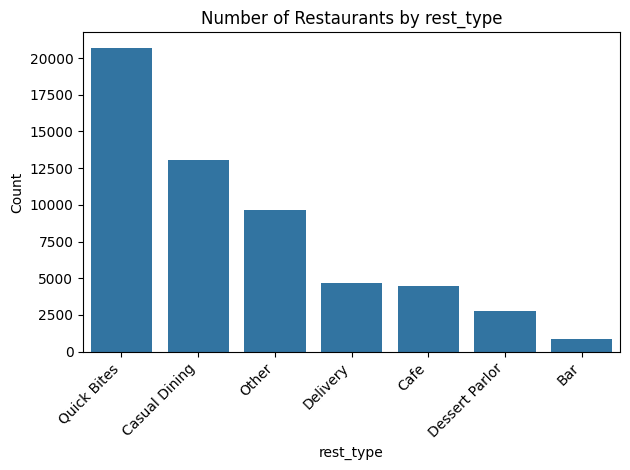

In [41]:
sns.barplot(x=df['rest_type'].value_counts().index, y=df['rest_type'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('rest_type')
plt.ylabel('Count')
plt.title('Number of Restaurants by rest_type')
plt.tight_layout()
plt.show()

In [42]:
df['cuisines'].value_counts()

North Indian                                                                                                        2913
North Indian, Chinese                                                                                               2385
South Indian                                                                                                        1828
Biryani                                                                                                              918
Bakery, Desserts                                                                                                     911
                                                                                                                    ... 
the service is a bit slow                                                                                              1
 sizzlers                                                                                                              1
 and the potion was suffice. The

In [43]:
def map_cuisine(cuisine):
    if pd.isnull(cuisine):
        return 'Other'
    cuisine = cuisine.lower()
    main_types = ['north indian', 'chinese', 'south indian', 'fast food', 'desserts','biryani','italian','mexican','cafe','continental','american','bakery','dessert','mithai','street food','arabian','seafood','thai','mediterranean','japanese','korean','fusion','grill','bengali','beverages','drinks']
    found = [typ for typ in main_types if typ in cuisine]
    if len(found) == 1:
        # Return the matched main type with proper capitalization
        return found[0].title()
    elif len(found) > 1:
        return 'Mixed/Other'
    else:
        return 'Other'

df['cuisines'] = df['cuisines'].apply(map_cuisine)
df['cuisines'].value_counts()


Mixed/Other      33163
Other             6591
North Indian      3842
South Indian      2292
Fast Food         2112
Biryani           1700
Chinese           1359
Cafe               974
Beverages          927
Bakery             692
Continental        518
Italian            416
Street Food        409
Seafood            247
Arabian            233
American           147
Bengali            136
Thai               103
Drinks              94
Japanese            93
Mexican             68
Dessert             42
Mediterranean       39
Korean              27
Grill               24
Fusion               4
Name: cuisines, dtype: int64

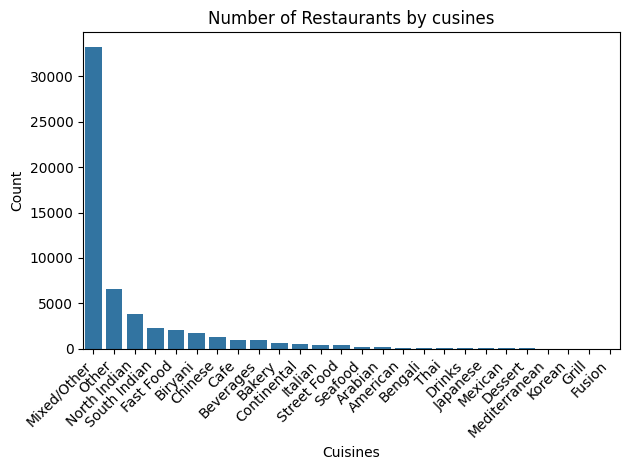

In [44]:
sns.barplot(x=df['cuisines'].value_counts().index, y=df['cuisines'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Cuisines')
plt.ylabel('Count')
plt.title('Number of Restaurants by cusines')
plt.tight_layout()
plt.show()

In [45]:

from collections import Counter

# Step 1: Count occurrences of each dish in 'dish_liked'
all_dishes = []
df['dish_liked'].dropna().apply(lambda x: all_dishes.extend([i.strip().lower() for i in x.split(',')]))
dish_counts = Counter(all_dishes)

# Step 2: Choose top N dishes
top_n = 10
top_dishes = set([dish for dish, count in dish_counts.most_common(top_n)])

# Step 3: Categorize each row by its most popular dish, or 'many dishes'
def categorize_dish_liked(dishes):
    if pd.isnull(dishes):
        return 'Many Dishes'
    dishes_list = [i.strip().lower() for i in dishes.split(',')]
    for dish in dishes_list:
        if dish in top_dishes:
            return dish.title()
    return 'Many Dishes'

df['dish_liked'] = df['dish_liked'].apply(categorize_dish_liked)
print(df['dish_liked'].value_counts())
# ...existing code...

Many Dishes    42713
Cocktails       1999
Burgers         1855
Biryani         1670
Pasta           1527
Coffee          1484
Paratha         1270
Pizza           1202
Noodles         1019
Sandwiches       837
Mocktails        676
Name: dish_liked, dtype: int64


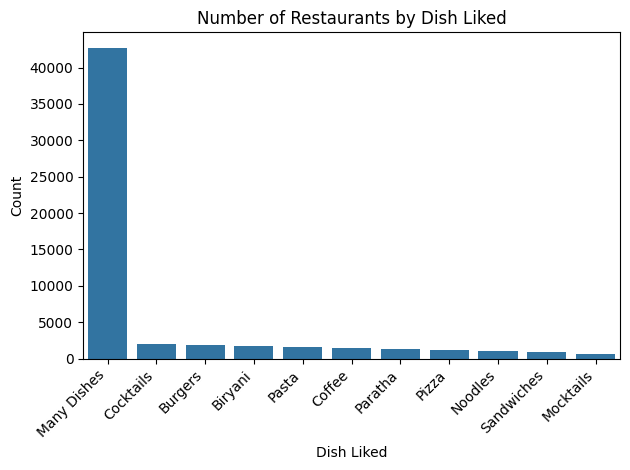

In [46]:
sns.barplot(x=df['dish_liked'].value_counts().index, y=df['dish_liked'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Dish Liked')
plt.ylabel('Count')
plt.title('Number of Restaurants by Dish Liked')
plt.tight_layout()
plt.show()

In [47]:
df.isna().sum()

address                           17
name                              16
online_order                       0
book_table                      4535
rate                           14587
votes                           4535
location                         126
rest_type                          0
dish_liked                         0
cuisines                           0
approx_cost(for two people)     4881
listed_in(type)                 4610
clean_rate                      4552
dtype: int64

In [48]:
# Impute missing values in 'online_order' and 'book_table' with the mode
for col in ['online_order', 'book_table']:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

# Impute missing values in 'rate' and 'votes' with the median
for col in ['rate', 'votes']:
    df[col] = df[col].fillna(df[col].median())

# Impute missing values in 'location', 'rest_type', 'cuisines',  with 'Unknown'
for col in ['location', 'rest_type', 'cuisines']:
    df[col] = df[col].fillna('Unknown')

# Check for missing values in the data again
df.isna().sum()

address                          17
name                             16
online_order                      0
book_table                        0
rate                              0
votes                             0
location                          0
rest_type                         0
dish_liked                        0
cuisines                          0
approx_cost(for two people)    4881
listed_in(type)                4610
clean_rate                     4552
dtype: int64

In [49]:
df['name'].value_counts()

 ('Rated 4.0'                                                                                                                                                                                                    300
 ('Rated 5.0'                                                                                                                                                                                                    235
 ('Rated 3.0'                                                                                                                                                                                                    113
Cafe Coffee Day                                                                                                                                                                                                   96
Onesta                                                                                                                                              

In [50]:
df['name'].nunique()

11914

In [51]:
df['phone'].nunique()

KeyError: 'phone'

In [ ]:
df['address'].nunique()

'''

    Since there are 11914 unique values for 'name' feature I am removing it. 

    Similarly in 'phone' feature there are 17712 unique values therefore I am removing it.
    
    Similarly for 'address' feature there are 13397 unique values....
    
'''

In [ ]:
# drop address, phone and missing values in dish_liked
df.drop(columns=['address', 'phone','name'], inplace=True)

In [ ]:
df.isna().sum()

In [ ]:


# Drop rows where 'dish_liked' or 'approx_cost(for two people)' is missing or 'Unknown'
df = df[
    (df['dish_liked'].notna()) &
    (df['dish_liked'] != 'Unknown') &
    (df['approx_cost(for two people)'].notna())
]


In [ ]:
df.head(10)

### EDA

In [ ]:
# 1. Distribution of Ratings
plt.figure(figsize=(8, 5))
sns.histplot(df['rate'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:
# 2. Votes vs. Rating
plt.figure(figsize=(8, 5))
sns.scatterplot(x='rate', y='votes', data=df, alpha=0.5)
plt.title('Votes vs. Rating')
plt.xlabel('Rating')
plt.ylabel('Votes')
plt.show()

In [ ]:
# 3. Average Cost by Location (Top 10)
top_locations = df['location'].value_counts().index[:10]
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='approx_cost(for two people)', data=df[df['location'].isin(top_locations)])
plt.xticks(rotation=45, ha='right')
plt.title('Approximate Cost for Two People by Location (Top 10)')
plt.xlabel('Location')
plt.ylabel('Approximate Cost (for two people)')
plt.tight_layout()
plt.show()

In [ ]:
# 4. Count of Restaurants by Rest Type
plt.figure(figsize=(10, 5))
sns.countplot(x='rest_type', data=df, order=df['rest_type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Restaurants by Rest Type')
plt.xlabel('Rest Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# 5. Count of Restaurants by Cuisine
plt.figure(figsize=(10, 5))
sns.countplot(x='cuisines', data=df, order=df['cuisines'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Restaurants by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# 6. Online Order vs. Rating
plt.figure(figsize=(6, 4))
sns.boxplot(x='online_order', y='rate', data=df)
plt.title('Rating Distribution by Online Order Availability')
plt.xlabel('Online Order (0=No, 1=Yes)')
plt.ylabel('Rating')
plt.show()

In [ ]:
# 7. Book Table vs. Rating
plt.figure(figsize=(6, 4))
sns.boxplot(x='book_table', y='rate', data=df)
plt.title('Rating Distribution by Table Booking Availability')
plt.xlabel('Book Table (0=No, 1=Yes)')
plt.ylabel('Rating')
plt.show()

In [ ]:
# Correlation heatmap for numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [ ]:
# Segment: Average rating by rest_type (to identify types with low ratings)
plt.figure(figsize=(10, 5))
sns.barplot(x='rest_type', y='rate', data=df, estimator=np.mean, order=df['rest_type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Average Rating by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

In [ ]:

# Segment: Average rating by location (top 10 locations)
top_locations = df['location'].value_counts().index[:10]
plt.figure(figsize=(12, 6))
sns.barplot(x='location', y='rate', data=df[df['location'].isin(top_locations)], estimator=np.mean)
plt.xticks(rotation=45, ha='right')
plt.title('Average Rating by Location (Top 10)')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()
